# 01 - Exploración de audio

Notebook inicial para la Fase 1 del proyecto.

Este cuaderno carga un archivo WAV, muestra información básica y grafica la señal en el dominio temporal.

In [5]:
# Celda temporal para la creacion de un audio para inyectarle una onda pura, y le sumamos una onda de frecuencia 2000Hz
# Esta nos sirve para probar la detección de frecuencias no deseadas en la fase 2, y también para probar la carga de audio en la fase 1. Es decir, es un entorno controlado, por ejemplo, si dependemos de un audio real, no sabemos exactamente qué frecuencias no deseadas tiene, y esto puede dificultar la depuración de nuestro código. En cambio, con un audio sintético, podemos asegurarnos de que contiene exactamente lo que queremos probar.
# NOTA: Usamos 2000 Hz en lugar de 60 Hz para que el "ruido" sea audible en cualquier parlante o audífono.
# 60 Hz es demasiado grave para que la mayoría de dispositivos de consumo lo reproduzcan.

import numpy as np
import soundfile as sf
from pathlib import Path

# Configuración básica
sample_rate = 44100
duration = 3.0 # segundos
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# 1. Señal original (Un tono puro de 440 Hz - la nota La)
signal_clean = 0.5 * np.sin(2 * np.pi * 440 * t)

# 2. Ruido no deseado (Silbido de 2000 Hz + un poco de ruido blanco)
noise_2000hz = 0.3 * np.sin(2 * np.pi * 2000 * t)
white_noise = np.random.normal(0, 0.1, signal_clean.shape)

# Mezclamos la señal con el ruido
noisy_signal = signal_clean + noise_2000hz + white_noise

# Guardamos el archivo sobrescribiendo nuestro ejemplo
output_path = Path("../data/raw/PruebaAN1.wav")
sf.write(output_path, noisy_signal, sample_rate)

print(f"¡Archivo sintético generado con éxito en: {output_path}!")

¡Archivo sintético generado con éxito en: ..\data\raw\PruebaAN1.wav!


## Paso 1: Creación de un audio de prueba controlado

Antes de trabajar con audio real, vamos a crear uno nosotros mismos. ¿Por qué? Porque si usamos un audio real, no sabemos exactamente qué frecuencias contiene, y eso dificulta verificar que nuestro análisis es correcto.

En cambio, al crear un audio sintético podemos decirle exactamente:
- qué nota musical queremos (440 Hz = la nota **La**)
- qué ruido queremos inyectarle (60 Hz = zumbido eléctrico típico)
- cuánto ruido aleatorio agregar (ruido blanco)

Así, cuando más adelante apliquemos la FFT y los filtros, sabremos exactamente qué debería aparecer y qué debería desaparecer.

Archivo: PruebaAN1.wav
Frecuencia de muestreo: 44100 Hz
Muestras: 132300
Duración aproximada: 3.00 s
Amplitud mínima: -1.0000
Amplitud máxima: 1.0000


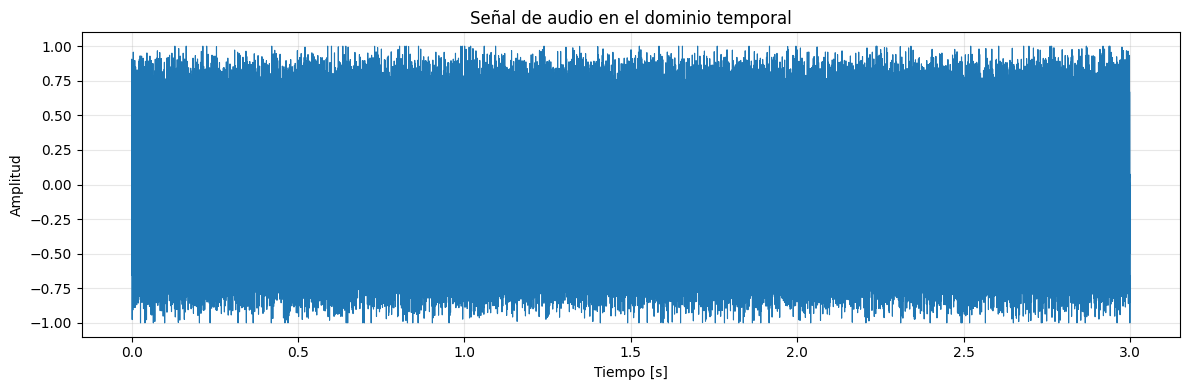

In [6]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Añadimos la carpeta raíz del proyecto al path para importar nuestros módulos. Vamos a llamar al audio_loader, que es el módulo encargado de cargar los archivos de audio. En la Fase 1 implementaremos su función load_audio.
sys.path.append("..")
from src.audio_loader import load_audio

# Definimos la ruta del archivo
AUDIO_PATH = Path("../data/raw/PruebaAN1.wav")
if not AUDIO_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo de audio en {AUDIO_PATH}. Coloca un WAV de prueba en data/raw/."
    )

# Haciendo uso de la arq. modular.
signal, sample_rate = load_audio(AUDIO_PATH)
duration = len(signal) / sample_rate

print(f"Archivo: {AUDIO_PATH.name}")
print(f"Frecuencia de muestreo: {sample_rate} Hz")
print(f"Muestras: {len(signal)}")
print(f"Duración aproximada: {duration:.2f} s")
print(f"Amplitud mínima: {signal.min():.4f}")
print(f"Amplitud máxima: {signal.max():.4f}")

# Eje de tiempo para la gráfica
time_axis = np.arange(len(signal)) / sample_rate

# Visualización en el dominio temporal
plt.figure(figsize=(12, 4))
plt.plot(time_axis, signal, linewidth=0.8)
plt.title("Señal de audio en el dominio temporal")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 2: Carga y visualización de la señal en el tiempo

Ahora cargamos el archivo de audio que acabamos de crear y lo convertimos en una lista de números que la computadora puede analizar.

Cada número representa la **amplitud** (volumen) de la onda sonora en un instante de tiempo. Con 44,100 muestras por segundo, un audio de 3 segundos se convierte en más de 130,000 números.

La gráfica que verás a continuación muestra cómo varía esa amplitud a lo largo del tiempo. Es lo que se llama el **dominio temporal** — el mismo tipo de gráfica que ves en aplicaciones como Audacity o GarageBand.

> 💡 En el dominio temporal puedes ver *cuándo* ocurre algo, pero no *qué frecuencias* están presentes. Para eso necesitamos la FFT.

## Siguiente paso

En la siguiente fase se aplicará FFT para obtener el espectro de frecuencias y empezar el análisis espectral.